<a href="https://colab.research.google.com/github/matthewhawksby/colabnotebooks/blob/main/Wav2vec2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Final Project CMPT419 - Affective Computing')

import os
import torch
import torchaudio
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.model_selection import KFold
from transformers import Wav2Vec2Processor, Wav2Vec2Model, get_scheduler
from torch import nn
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt
from verbio_dataset import VerBIOAudioStressDataset

class Wav2Vec2ForRegression(nn.Module):
    def __init__(self, pretrained_name="facebook/wav2vec2-base", dropout=0.1):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(pretrained_name)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(self.wav2vec2.config.hidden_size, 1)

    def forward(self, input_values):
        outputs = self.wav2vec2(input_values)
        hidden_states = outputs.last_hidden_state
        pooled = self.pooling(hidden_states.transpose(1, 2)).squeeze(-1)
        pooled = self.dropout(pooled)
        return self.regressor(pooled).squeeze(-1)

class ConcordanceCorrCoefLoss(torch.nn.Module):
    def forward(self, preds, target):
        preds_mean = torch.mean(preds)
        target_mean = torch.mean(target)

        cov = torch.mean((preds - preds_mean) * (target - target_mean))
        pred_var = torch.var(preds, unbiased=False)
        target_var = torch.var(target, unbiased=False)

        denominator = pred_var + target_var + (preds_mean - target_mean) ** 2
        denominator = torch.clamp(denominator, min=1e-6)  # Avoid divide-by-zero

        ccc = (2 * cov) / denominator
        return 1 - ccc


def load_dataset(folders):
    datasets = []
    for folder in folders:
        full_path = os.path.join(BASE_DIR, folder)
        datasets.append(VerBIOAudioStressDataset(full_path))
    return ConcatDataset(datasets)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:




BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/VerBIO_v2"
all_folders = sorted([f for f in os.listdir(BASE_DIR) if f.startswith("TEST")])

kf = KFold(n_splits=8, shuffle=True, random_state=42)
all_indices = list(range(len(all_folders)))

for fold, (train_idx, val_idx) in enumerate(kf.split(all_indices)):
    print(f"Fold {fold + 1}")
    train_folders = [all_folders[i] for i in train_idx]
    val_folders = [all_folders[i] for i in val_idx]

    train_dataset = load_dataset(train_folders)
    val_dataset = load_dataset(val_folders)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=8)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=8)

    model = Wav2Vec2ForRegression().cuda()
    criterion = ConcordanceCorrCoefLoss()
    optimizer = AdamW(model.parameters(), lr=2e-5)
    scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=len(train_loader)*5)
    should_stop = False

    checkpoint_dir = "/content/drive/MyDrive/Colab Notebooks/Final Project CMPT419 - Affective Computing/checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)


    for epoch in range(3):
        model.train()
        running_loss = 0.0

        for audio, labels, weights in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            audio = audio.cuda()
            labels = labels.cuda()
            weights = weights.cuda()

            preds = model(audio)
            base_loss = criterion(preds, labels)
            loss = (base_loss * weights).mean()

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"[Epoch {epoch+1}] NaN or Inf loss encountered. Stopping early.")
                should_stop = True
                break

            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            running_loss += loss.item()

        if should_stop:
            break

        print(f"Epoch {epoch+1} Loss: {running_loss / len(train_loader):.4f}")

    torch.save(model.state_dict(), f"{checkpoint_dir}/fold_{fold}_epoch_{epoch+1}.pt")


    # Optional: Evaluate after each fold
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for audio, labels, _ in val_loader:
            audio = audio.cuda()
            labels = labels.cuda()
            outputs = model(audio)
            preds.extend(outputs.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    # Plot predictions vs true labels for the validation set
    plt.figure(figsize=(15, 5))
    plt.plot(targets, label="True", marker='o', color='blue')
    plt.plot(preds, label="Pred", marker='x', color='red', alpha=0.6)
    plt.legend()
    plt.title(f"Fold {fold+1} Predictions")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


#drive.mount('/content/drive')
#save_dir = "/content/drive/MyDrive/Colab Notebooks/Final Project CMPT419 - Affective Computing/wav2vec2_large_emotion"

#model_name = "facebook/wav2vec2-base"

#model = Wav2Vec2Model.from_pretrained(model_name)
#processor = Wav2Vec2Processor.from_pretrained(model_name)

#model.save_pretrained(save_dir)
#processor.save_pretrained(save_dir)
#print(f"Model saved to: {save_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fold 1


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:315: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


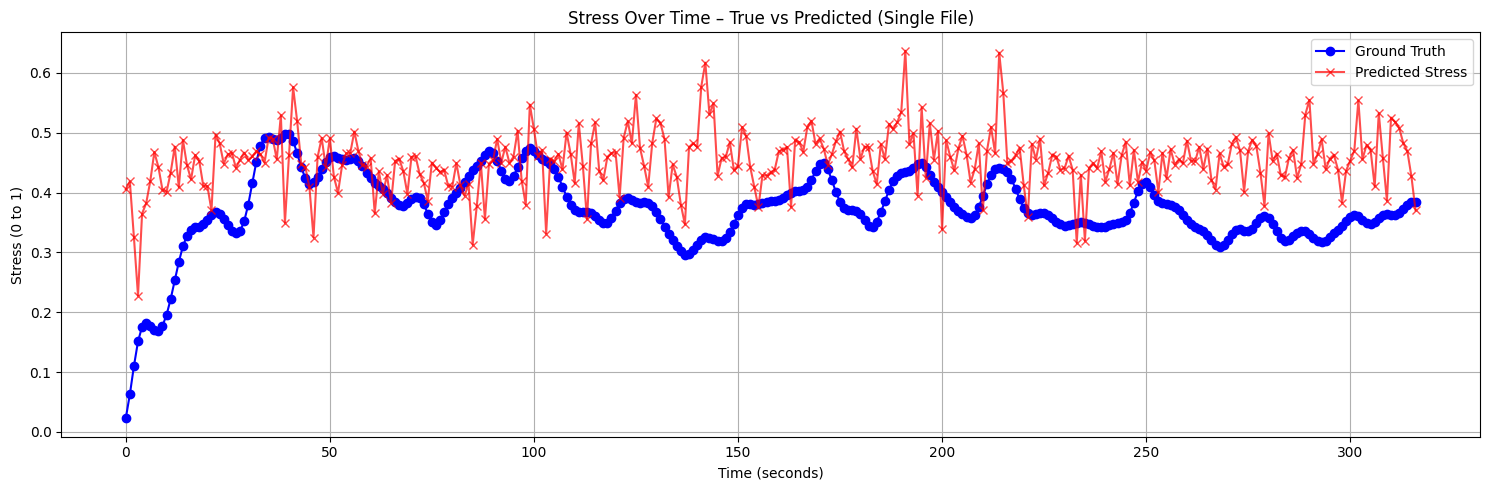

In [8]:
import torchaudio
import torch
import pandas as pd

# Paths
audio_path = "/content/drive/MyDrive/Colab Notebooks/VerBIO_v2/TEST08/Audio/TEST08_P004_AUDIO_PPT.wav"
label_path = "/content/drive/MyDrive/Colab Notebooks/VerBIO_v2/TEST08/Annotation/TEST08_P004_annotation.csv"
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/Final Project CMPT419 - Affective Computing/checkpoints/fold_1_epoch_3.pt"

# Load audio
waveform, sr = torchaudio.load(audio_path)
if sr != 16000:
    resampler = torchaudio.transforms.Resample(sr, 16000)
    waveform = resampler(waveform)
waveform = waveform[0]  # convert to mono

# Load labels
df = pd.read_csv(label_path)
fused_labels = df["Fused"].values

# Segment audio
segment_samples = 16000
num_segments = min(len(fused_labels), waveform.shape[0] // segment_samples)
segments = []
for i in range(num_segments):
    start = i * segment_samples
    end = start + segment_samples
    segments.append(waveform[start:end])
segments = torch.stack(segments).to("cuda")

# Load model and checkpoint
model = Wav2Vec2ForRegression().to("cuda")
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

# Inference
with torch.no_grad():
    predictions = model(segments).cpu().numpy()

# Optional: compare to labels
ground_truth = fused_labels[:len(predictions)]

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(ground_truth, label='Ground Truth', color='blue', marker='o')
plt.plot(predictions, label='Predicted Stress', color='red', alpha=0.7, marker='x')
plt.title("Stress Over Time – True vs Predicted (Single File)")
plt.xlabel("Time (seconds)")
plt.ylabel("Stress (0 to 1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
#Creating the dataloader and loading it with

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Final Project CMPT419 - Affective Computing')

from torch.utils.data import DataLoader
from verbio_dataset import VerBIOAudioStressDataset

dataset = VerBIOAudioStressDataset(
    root_dir="/content/drive/MyDrive/Colab Notebooks/VerBIO_v2/TEST01"
)

print(f"Loaded {len(dataset)} 1-second audio segments.")
print("Sample shape:", dataset[0][0].shape, "Label:", dataset[0][1])


dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

for batch in dataloader:
    audio_batch, label_batch, weight_batch = batch
    print(audio_batch.shape)  # [16, 16000]
    print(label_batch.shape)  # [16]
    break


Loaded 8553 1-second audio segments.
Sample shape: torch.Size([16000]) Label: 0.0183188110938229
torch.Size([16, 16000])
torch.Size([16])


In [3]:
import torch
import torch.nn as nn

class Wav2Vec2ForRegression(nn.Module):
    def __init__(self, pretrained_name="facebook/wav2vec2-large-960h", dropout=0.1):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(pretrained_name)
        self.pooling = nn.AdaptiveAvgPool1d(1)  # mean pooling over time dimension
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(self.wav2vec2.config.hidden_size, 1)

    def forward(self, input_values, attention_mask=None):
        outputs = self.wav2vec2(input_values, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state  # (batch, time, features)

        # Transpose for pooling: (batch, features, time)
        pooled = self.pooling(hidden_states.transpose(1, 2)).squeeze(-1)  # (batch, features)
        pooled = self.dropout(pooled)

        return self.regressor(pooled).squeeze(-1)  # (batch)


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Wav2Vec2ForRegression().to(device)


batch = next(iter(dataloader))
audio_batch, label_batch, weight_batch = batch
audio_batch = audio_batch.to(device)

with torch.no_grad():
    preds = model(audio_batch)

print(preds.shape)  # Should be [batch_size]


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([16])


In [5]:
import torch

class ConcordanceCorrCoefLoss(torch.nn.Module):
    def forward(self, preds, target):
        preds_mean = torch.mean(preds)
        target_mean = torch.mean(target)

        cov = torch.mean((preds - preds_mean) * (target - target_mean))
        pred_var = torch.var(preds)
        target_var = torch.var(target)

        ccc = (2 * cov) / (pred_var + target_var + (preds_mean - target_mean) ** 2 + 1e-8)
        return 1 - ccc  # 1 - CCC = loss to minimize


In [6]:
import numpy as np




In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers.optimization import get_scheduler
from tqdm import tqdm

# Device
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
#model = Wav2Vec2ForRegression().to(device)

# Dataloader (already have this!)
#train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

# Loss
#criterion = nn.MSELoss()
criterion = ConcordanceCorrCoefLoss()


# Optimizer & scheduler
optimizer = AdamW(model.parameters(), lr=2e-5)
num_epochs = 10
num_training_steps = num_epochs * len(dataloader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)


In [8]:
model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for audio, labels, weights in loop:
        audio = audio.to(device)
        labels = labels.to(device)
        weights = weights.to(device)

        preds = model(audio)

        base_loss = criterion(preds, labels)

        # Apply sample-wise weights (same shape as batch)
        loss = (base_loss * weights).mean()

        # Backprop
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        loop.set_postfix(loss=loss.item())
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {epoch_loss / len(dataloader):.4f}")



Epoch 1/10: 100%|██████████| 535/535 [01:07<00:00,  7.92it/s, loss=0.0235]


Epoch 1 Loss: 0.0188


Epoch 2/10: 100%|██████████| 535/535 [01:07<00:00,  7.95it/s, loss=0.0149]


Epoch 2 Loss: 0.0171


Epoch 3/10: 100%|██████████| 535/535 [01:06<00:00,  8.00it/s, loss=0.0328]


...

Epoch 8 Loss: 0.0101


Epoch 9/10: 100%|██████████| 535/535 [01:07<00:00,  7.94it/s, loss=0.0111]


Epoch 9 Loss: 0.0096


Epoch 10/10: 100%|██████████| 535/535 [01:07<00:00,  7.95it/s, loss=0.00627]

Epoch 10 Loss: 0.0092


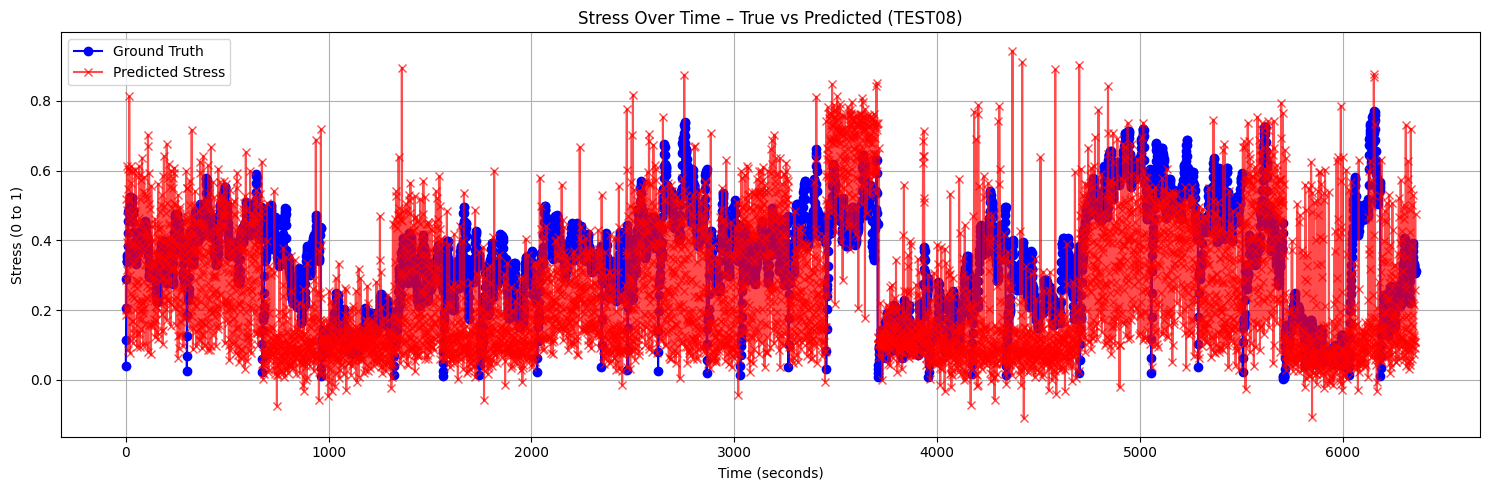

In [10]:
#Let's test against the 8th folder of data. Ground truth vs predicted label.

import matplotlib.pyplot as plt

# 1. Load the test dataset (adjust path as needed)
test_dataset = VerBIOAudioStressDataset(
    "/content/drive/MyDrive/Colab Notebooks/VerBIO_v2/TEST08"
)
test_loader = DataLoader(test_dataset, batch_size=16)

# 2. Move model to eval mode
model.eval()

all_preds = []
all_labels = []

# 3. Inference
with torch.no_grad():
    for audio, labels, weights in test_loader:
        audio = audio.to(device)
        labels = labels.to(device)
        weights = weights.to(device)

        preds = model(audio)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 4. Plot
plt.figure(figsize=(15, 5))
plt.plot(all_labels, label='Ground Truth', color='blue', marker='o')
plt.plot(all_preds, label='Predicted Stress', color='red', alpha=0.7, marker='x')
plt.title("Stress Over Time – True vs Predicted (TEST08)")
plt.xlabel("Time (seconds)")
plt.ylabel("Stress (0 to 1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#This part is from testing the CTC model.
#Get a sample audio file
#!wget -O "/content/drive/MyDrive/Colab Notebooks/Final Project CMPT419 - Affective Computing/SampleAudioFiles/sample1.wav" "https://www.voiptroubleshooter.com/open_speech/american/OSR_us_000_0030_8k.wav"

#audio_file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project CMPT419 - Affective Computing/SampleAudioFiles/sample1.wav"
#waveform, sample_rate = librosa.load(audio_file_path, sr=16000)
#print(audio_file_path)

# Resample the audio to 16kHz for wav2vec2
#waveform, sample_rate = librosa.load(audio_file_path, sr=16000)
#input_values = processor(waveform, return_tensors="pt", sampling_rate=16000).input_values

# Run inference#
#with torch.no_grad():
#    logits = model(input_values).logits

# Speech 2 Text
#predicted_ids = torch.argmax(logits, dim=-1)
#transcription = processor.batch_decode(predicted_ids)[0]

#print("Transcription:", transcription)
#print("Logits shape:", logits.shape)


In [ ]:
#Let's look at the architecture of the model
#print(model)

In [ ]:
#Let's look at all named components now.
for name, module in model.named_children():
    print(name, "->", module)

In [ ]:
#And now let's look at all the layers including sublayers.
for name, param in model.named_parameters():
    print(name, param.shape)